In [4]:
import seaborn as sns
import scipy.stats as stats
import pandas as pd
import os

In [2]:
def plot_density(cell):
    # Set the style
    sns.set(style="white")
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_immune[cell], label='Immune Enhancers', color='blue', linestyle='-', linewidth=1.5,fill=True)
    sns.kdeplot(df_other[cell], label='Low ATAC Enhancers', color='black', linestyle='-', linewidth=1.5,fill=True)
    sns.kdeplot(df_ubiquitous[cell], label='Ubiquitous Enhancers', color='red', linestyle='-', linewidth=1.5,fill=True)
    # Adding labels and title
    plt.xlabel(f'{cell} Enhancer MAD Scores of Transcription')
    plt.ylabel('Density')
    plt.title(f'{cell}')
    # Adding legend
    plt.legend(title='Enhancer Type')
    # Show the plot
    plt.savefig(f'densityplot_enhancer_type_{cell}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # Assume df_immune['THP1_LPSIFNG'] and df_other['THP1_LPSIFNG'] are your two independent samples.
    result1 = stats.mannwhitneyu(df_immune[cell], df_other[cell], alternative='two-sided')
    result2 = stats.mannwhitneyu(df_ubiquitous[cell], df_other[cell], alternative='two-sided')
    print("immune vs other; p-value:", result1.pvalue)
    print("ubiquitous vs other; p-value:", result2.pvalue)

In [5]:
############################################################
# Step 1: Reading MAD Scores and Merging with Index/Annotations
############################################################

# List of keyword patterns to search for in filenames
keywords = [
    'THP1Macrophage', 'Brain', 'HEK293T', 'Cortex', 'Striatum', 'Hippocampus','HMC3Cell',
    'HMC3_IFNB', 'HMC3_IFNG', 'HMC3_Naive', 'HMC3_LPSIFNG', 'THP1Monocyte',
    'THP1_Naive', 'THP1_IFNG', 'THP1_IFNB', 'THP1_LPSIFNG'
]

# Directory containing your MAD score CSV files
path = 'enhancer_activities/MAD_OneTail_NoControl/'

# Initialize an empty DataFrame to store combined results
df = pd.DataFrame()

# Loop through each keyword and each file in the directory
for key in keywords:
    for f in os.listdir(path):
        if (
            key in f
            and "old" not in f
            and "hold" not in f
            and not f.startswith("._")
        ):
            df_new = pd.read_csv(
                os.path.join(path, f),
                index_col=0
            )["pval.mad"]

            df_new = pd.DataFrame(df_new)
            df_new.columns = [key]
            df = pd.concat([df, df_new], axis=1)

# Load indexing files (metadata)
df_index = pd.read_csv(
    'indexing/ALT_REF_LookUpTable_filtered_amended_alleleOnly_20240605.csv',
    index_col=0
)
df_annotation = pd.read_csv(
    'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310.csv',
    index_col=0
)

# Merge df_index and df_annotation
df_index_annotation = pd.merge(df_index, df_annotation, left_index=True, right_index=True)

# Filter df to keep rows whose index starts with 'alt' or 'ref'
mask = df.index.astype(str).str.startswith('alt') | df.index.astype(str).str.startswith('ref')
filtered_df = df[mask]

# Merge filtered_df with annotation to get separate alt/ref data
df_alt = pd.merge(filtered_df, df_index_annotation, left_index=True, right_index=True)
df_ref = pd.merge(filtered_df, df_index_annotation.set_index("1"), left_index=True, right_index=True)

# Combine alt and ref, reorder to match original
df_mpra_annotation = pd.concat([df_alt, df_ref]).loc[filtered_df.index]

# Create a column for absolute distance to TSS
df_mpra_annotation['absoluate_distance_to_tss'] = df_mpra_annotation['distance_to_tss'].abs()

# Remove duplicated rows based on index, keeping the first occurrence
df_mpra_annotation_unique = df_mpra_annotation[~df_mpra_annotation.index.duplicated(keep='first')]
df_mpra_annotation_unique

/var/folders/sh/7r2k6xws40df6nh1bf5t_1x40000gn/T/ipykernel_53963/3681954048.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mpra_annotation['absoluate_distance_to_tss'] = df_mpra_annotation['distance_to_tss'].abs()


,THP1Macrophage,Brain,HEK293T,Cortex,Striatum,Hippocampus,HMC3Cell,HMC3_IFNB,HMC3_IFNG,HMC3_Naive,...,VIP,VIP_1,VIP_2,VIP_3,VIP_4,VIP_5,VIP_6,VIP_7,Variant_Category,absoluate_distance_to_tss
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,0.001765,0.188590,0.010447,0.322655,0.519032,0.316151,0.150031,0.156222,0.086246,0.042867,...,1,1,1,1,1,1,1,1,Broad,1547
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,0.837334,0.639903,0.983199,0.799595,0.673714,0.776677,0.958347,0.951750,0.972169,0.970266,...,0,0,0,0,0,0,0,0,Low-ATAC,28082
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,0.054455,0.150777,0.028097,0.814269,0.681148,0.512242,0.243805,0.394417,0.161525,0.066196,...,1,1,1,1,1,1,1,1,Broad,950
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,0.973911,0.821705,0.930123,0.583045,0.522951,0.684094,0.907126,0.917069,0.856296,0.928403,...,0,0,0,0,0,0,0,0,Immune-enriched,799
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,0.954601,0.969509,0.926855,0.964454,0.933899,0.971509,0.867091,0.869490,0.842528,0.887963,...,0,0,0,0,0,0,0,0,Broad,523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ref:rs9281938:PEAKCENTER:chr6:32576282:T:TA:32576044:32576544:32576294,0.333542,0.933314,0.813532,0.916938,0.946217,0.914545,0.568131,0.675672,0.506487,0.450971,...,0,0,0,0,0,0,0,0,Immune-enriched,18657
ref:rs9304646:PEAKCENTER:chr19:44947151:T:A:44946977:44947477:44947227,0.295088,0.856594,0.582507,0.916202,0.769515,0.793902,0.258771,0.323283,0.166683,0.145644,...,0,0,0,0,0,0,0,0,Immune-enriched,1116
ref:rs9357546:PEAKCENTER:chr6:47549495:C:T:47549371:47549664:47549511,0.960112,0.830979,0.686254,0.925415,0.892002,0.639602,0.597486,0.635336,0.611141,0.527484,...,0,0,0,0,0,0,0,0,Immune-enriched,19137
ref:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,0.624618,0.071043,0.075736,0.049827,0.078954,0.133840,0.125426,0.201565,0.086813,0.052988,...,0,0,0,0,0,0,0,0,Immune-enriched,4787


In [6]:
for i in df_mpra_annotation_unique.columns:
    print(i)

THP1Macrophage
Brain
HEK293T
Cortex
Striatum
Hippocampus
HMC3Cell
HMC3_IFNB
HMC3_IFNG
HMC3_Naive
HMC3_LPSIFNG
THP1Monocyte
THP1_Naive
THP1_IFNG
THP1_IFNB
THP1_LPSIFNG
1
RSID
Contributor
nearest_gene
rsID
chr_number
pos_hg38
ref
alt
AFR
AMR
ASN
EUR
MAF_Average
Rare_Common
Rare_Low_Common
GERP_cons
SiPhy_cons
Chromatin_States
Chromatin_States_Imputed
Chromatin_Marks
DNAse
Proteins
eQTL
gwas
grasp
Motifs
GENCODE_id
GENCODE_name
GENCODE_direction
GENCODE_distance
RefSeq_id
RefSeq_name
RefSeq_direction
RefSeq_distance
dbSNP_functional_annotation
query_snp_rsid
Promoter_histone_marks
Enhancer_histone_marks
snp_original
snp_original_haploreghg38
SNP_ID
REFALT_Flip
allele
rsid
center
chr
snp
a1
a1_spliceai
a2
a2_spliceai
start
end
summit
Mef2
PU.1
Irf
STAT
NF-kappaB
AP-1
Major
Minor
Rare_Common.1
rsid_nearestgene
coordinate
cpg_inter
cpg_islands
cpg_shelves
cpg_shores
genes_1to5kb
genes_3UTRs
genes_5UTRs
genes_exons
genes_intergenic
genes_intronexonboundaries
genes_introns
genes_promoters
Enco


Summary table using p < 0.1:
              CRE_type  total_count  significant_count          sample  \
0          Immune CREs          571                126  THP1Macrophage   
1        Neuronal CREs           86                  8  THP1Macrophage   
2           Broad CREs          515                 84  THP1Macrophage   
3           Glial CREs           53                  7  THP1Macrophage   
4   Low ATAC Sequences          190                 34  THP1Macrophage   
5          Immune CREs          571                105           Brain   
6        Neuronal CREs           86                 19           Brain   
7           Broad CREs          515                 76           Brain   
8           Glial CREs           53                  6           Brain   
9   Low ATAC Sequences          190                 34           Brain   
10         Immune CREs          571                102         HEK293T   
11       Neuronal CREs           86                 11         HEK293T   
12      

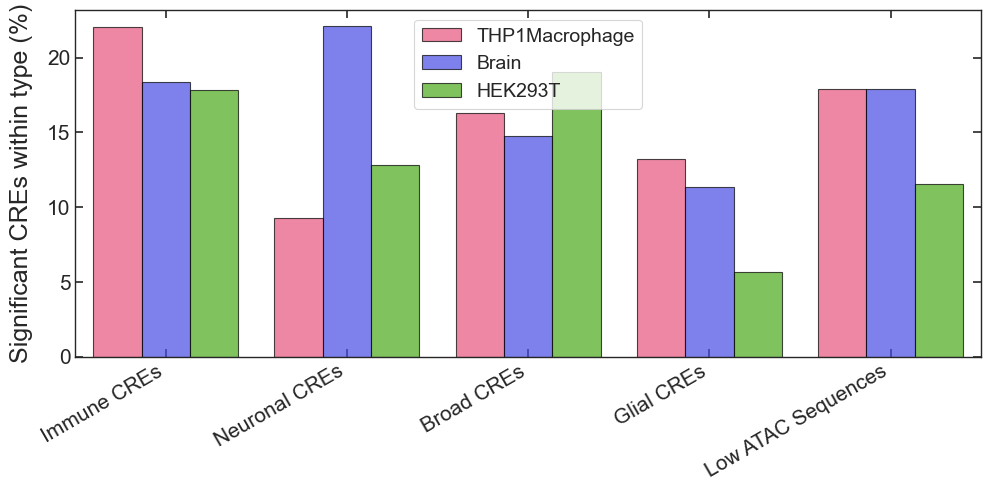


Overall chi-square tests using p < 0.1:
           sample       chi2  dof    pvalue  min_expected    qvalue
0  THP1Macrophage  12.376190    4  0.014762      9.701060  0.029022
1         HEK293T  11.745452    4  0.019348      8.839576  0.029022
2           Brain   5.525158    4  0.237527      8.989399  0.237527

==================== THP1Macrophage ====================

Observed table:
sig_group           p<0.1  p>=0.1
CRE_type                         
Low ATAC Sequences     34     156
Immune CREs           126     445
Broad CREs             84     431
Neuronal CREs           8      78
Glial CREs              7      46

Expected table:
sig_group            p<0.1  p>=0.1
CRE_type                          
Low ATAC Sequences   34.78  155.22
Immune CREs         104.52  466.48
Broad CREs           94.27  420.73
Neuronal CREs        15.74   70.26
Glial CREs            9.70   43.30

Standardized residuals:
sig_group           p<0.1  p>=0.1
CRE_type                         
Low ATAC Sequences 

In [7]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


# =========================================================
# Make text editable in Illustrator
# =========================================================
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.family'] = 'Arial'


# =========================================================
# 1. Settings
# =========================================================
sample_cols = [
    'THP1Macrophage',
    'Brain',
    'HEK293T'
]

# Significant CRE threshold: p < 0.1
p_thresh = 0.1


cat_map = {
    'Low-ATAC': 'Low ATAC Sequences',
    'Immune-enriched': 'Immune CREs',
    'Broad': 'Broad CREs',
    'Neuronal-enriched': 'Neuronal CREs',
    'Glial-enriched': 'Glial CREs',
}


color_map_sample = {
    'Brain': '#2D33FF',
    'THP1Macrophage': '#FF3B73',
    'HEK293T': '#43C000',
}


# Order used in the grouped bar plot
bar_plot_order = [
    'Immune CREs',
    'Neuronal CREs',
    'Broad CREs',
    'Glial CREs',
    'Low ATAC Sequences',
]


# Order used when printing chi-square contingency tables
chi2_plot_order = [
    'Low ATAC Sequences',
    'Immune CREs',
    'Broad CREs',
    'Neuronal CREs',
    'Glial CREs',
]


# =========================================================
# 2. Build long summary table
# =========================================================
all_summary = []

for sample_col in sample_cols:

    df_plot = df_mpra_annotation_unique[
        df_mpra_annotation_unique['Variant_Category'].isin(cat_map.keys())
    ].copy()

    df_plot = df_plot[
        ['Variant_Category', sample_col]
    ].copy()

    # Convert p-values to numeric
    df_plot[sample_col] = pd.to_numeric(
        df_plot[sample_col],
        errors='coerce'
    )

    # Remove missing p-values
    df_plot = df_plot.dropna(
        subset=[sample_col]
    ).copy()

    # Rename CRE categories
    df_plot['CRE_type'] = df_plot['Variant_Category'].map(cat_map)

    # Significant CRE definition: p < 0.1
    df_plot['significant'] = df_plot[sample_col] < p_thresh

    summary = (
        df_plot
        .groupby('CRE_type')
        .agg(
            total_count=('significant', 'size'),
            significant_count=('significant', 'sum')
        )
        .reindex(bar_plot_order)
        .reset_index()
    )

    summary['sample'] = sample_col

    summary['significant_fraction'] = (
        summary['significant_count']
        / summary['total_count']
    )

    summary['significant_fraction_pct'] = (
        summary['significant_fraction'] * 100
    )

    all_summary.append(summary)


summary_long = pd.concat(
    all_summary,
    axis=0,
    ignore_index=True
)


print("\nSummary table using p < 0.1:")
print(summary_long)


# Save the summary table
summary_long.to_csv(
    'grouped_bar_significant_fraction_p01_summary.csv',
    index=False
)


# =========================================================
# 3. Plot grouped bar plot
# =========================================================
sns.set(
    style='ticks',
    context='paper'
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)


sns.barplot(
    data=summary_long,
    x='CRE_type',
    y='significant_fraction_pct',
    hue='sample',
    order=bar_plot_order,
    hue_order=sample_cols,
    palette=color_map_sample,
    edgecolor='black',
    errorbar=None,
    ax=ax
)


# Set transparency
for patch in ax.patches:
    patch.set_alpha(0.7)


# Axis labels
ax.set_xlabel(
    '',
    fontsize=18
)

ax.set_ylabel(
    'Significant CREs within type (%)',
    fontsize=18,
    labelpad=10
)


# X-axis labels
ax.set_xticks(
    range(len(bar_plot_order))
)

ax.set_xticklabels(
    bar_plot_order,
    rotation=30,
    ha='right',
    fontsize=15
)


# Tick formatting
ax.tick_params(
    axis='both',
    which='both',
    direction='in',
    top=True,
    right=True,
    labelsize=15,
    length=6,
    width=1.2
)


# Legend
legend = ax.legend(
    title='',
    frameon=True,
    fontsize=14,
    title_fontsize=15
)


# Keep all four spines
sns.despine(
    top=False,
    right=False
)


plt.tight_layout()


# Save PDF
plt.savefig(
    'grouped_bar_Brain_HEK293T_THP1Macrophage_'
    'significant_fraction_p01.pdf',
    bbox_inches='tight'
)


# Save SVG
plt.savefig(
    'grouped_bar_Brain_HEK293T_THP1Macrophage_'
    'significant_fraction_p01.svg',
    bbox_inches='tight'
)


plt.show()


# =========================================================
# 4. Helper function: Benjamini-Hochberg FDR
# =========================================================
def bh_fdr(pvals):
    """
    Perform Benjamini-Hochberg FDR correction.
    """

    pvals = np.asarray(
        pvals,
        dtype=float
    )

    n = len(pvals)

    order = np.argsort(pvals)
    ranked_pvals = pvals[order]

    adjusted = (
        ranked_pvals
        * n
        / np.arange(1, n + 1)
    )

    # Enforce monotonicity
    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    output = np.empty_like(adjusted)
    output[order] = adjusted

    return output


# =========================================================
# 5. Chi-square test within each assay context
# =========================================================
chi2_results = []

residual_tables = {}
expected_tables = {}
observed_tables = {}


sig_label = f'p<{p_thresh:g}'
nonsig_label = f'p>={p_thresh:g}'


for sample_col in sample_cols:

    df_plot = df_mpra_annotation_unique[
        df_mpra_annotation_unique['Variant_Category'].isin(
            cat_map.keys()
        )
    ].copy()

    df_plot = df_plot[
        ['Variant_Category', sample_col]
    ].copy()

    # Convert p-values to numeric
    df_plot[sample_col] = pd.to_numeric(
        df_plot[sample_col],
        errors='coerce'
    )

    # Remove missing p-values
    df_plot = df_plot.dropna(
        subset=[sample_col]
    ).copy()

    # Rename CRE categories
    df_plot['CRE_type'] = df_plot['Variant_Category'].map(
        cat_map
    )

    # Divide sequences into significant and non-significant groups
    df_plot['sig_group'] = np.where(
        df_plot[sample_col] < p_thresh,
        sig_label,
        nonsig_label
    )

    # -----------------------------------------------------
    # Create 5 x 2 contingency table
    # -----------------------------------------------------
    contingency = (
        pd.crosstab(
            df_plot['CRE_type'],
            df_plot['sig_group']
        )
        .reindex(
            index=chi2_plot_order,
            columns=[sig_label, nonsig_label],
            fill_value=0
        )
    )

    observed = contingency.values

    # Chi-square test
    chi2, pval, dof, expected = chi2_contingency(
        observed
    )

    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )

    # Pearson standardized residuals
    residual_df = (
        contingency - expected_df
    ) / np.sqrt(expected_df)

    # Store tables
    observed_tables[sample_col] = contingency
    expected_tables[sample_col] = expected_df
    residual_tables[sample_col] = residual_df

    chi2_results.append({
        'sample': sample_col,
        'chi2': chi2,
        'dof': dof,
        'pvalue': pval,
        'min_expected': expected_df.min().min()
    })


# =========================================================
# 6. FDR correction across assay contexts
# =========================================================
chi2_df = pd.DataFrame(
    chi2_results
)

chi2_df['qvalue'] = bh_fdr(
    chi2_df['pvalue'].values
)

chi2_df = chi2_df.sort_values(
    'qvalue'
).reset_index(drop=True)


print("\nOverall chi-square tests using p < 0.1:")
print(chi2_df)


# Save overall chi-square results
chi2_df.to_csv(
    'chi_square_CRE_category_significance_p01.csv',
    index=False
)


# =========================================================
# 7. Print and save observed, expected, and residual tables
# =========================================================
for sample_col in sample_cols:

    print(
        f"\n==================== "
        f"{sample_col} "
        f"===================="
    )

    print("\nObserved table:")
    print(
        observed_tables[sample_col]
    )

    print("\nExpected table:")
    print(
        expected_tables[sample_col].round(2)
    )

    print("\nStandardized residuals:")
    print(
        residual_tables[sample_col].round(2)
    )

    # Save individual tables
    observed_tables[sample_col].to_csv(
        f'{sample_col}_observed_contingency_p01.csv'
    )

    expected_tables[sample_col].to_csv(
        f'{sample_col}_expected_contingency_p01.csv'
    )

    residual_tables[sample_col].to_csv(
        f'{sample_col}_standardized_residuals_p01.csv'
    )

              CRE_type  active_count          sample  \
0          Immune CREs           126  THP1Macrophage   
1        Neuronal CREs             8  THP1Macrophage   
2           Broad CREs            84  THP1Macrophage   
3           Glial CREs             7  THP1Macrophage   
4   Low ATAC Sequences            34  THP1Macrophage   
5          Immune CREs           105           Brain   
6        Neuronal CREs            19           Brain   
7           Broad CREs            76           Brain   
8           Glial CREs             6           Brain   
9   Low ATAC Sequences            34           Brain   
10         Immune CREs           102         HEK293T   
11       Neuronal CREs            11         HEK293T   
12          Broad CREs            98         HEK293T   
13          Glial CREs             3         HEK293T   
14  Low ATAC Sequences            22         HEK293T   

    active_fraction_within_sample  active_fraction_pct  
0                        0.486486            4

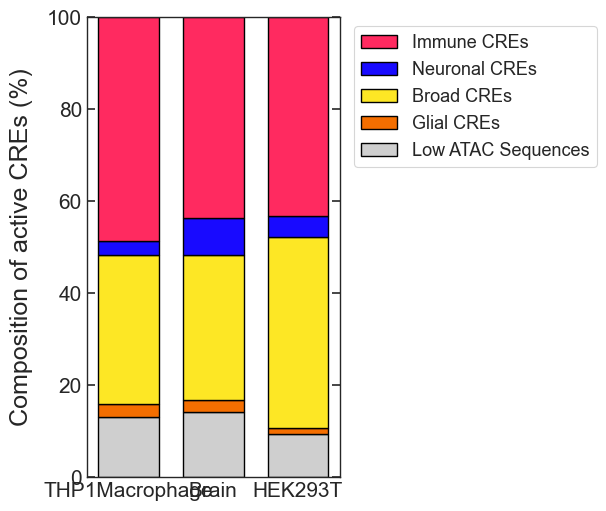

In [9]:
# =========================================================
# CRE order
# Desired order from TOP to BOTTOM:
# Immune, Neuronal, Broad, Glial, Low ATAC
# =========================================================
legend_order = [
    'Immune CREs',
    'Neuronal CREs',
    'Broad CREs',
    'Glial CREs',
    'Low ATAC Sequences',
]

# Matplotlib stacks bars from bottom to top,
# so the plotting order must be reversed
stack_order = legend_order[::-1]


# =========================================================
# 1. build active-hit composition table
# =========================================================
all_active_summary = []

for sample_col in sample_cols:
    df_plot = df_mpra_annotation_unique[
        df_mpra_annotation_unique['Variant_Category'].isin(cat_map.keys())
    ].copy()

    df_plot = df_plot[['Variant_Category', sample_col]].copy()
    df_plot[sample_col] = pd.to_numeric(
        df_plot[sample_col],
        errors='coerce'
    )
    df_plot = df_plot.dropna(subset=[sample_col]).copy()

    df_plot['CRE_type'] = df_plot['Variant_Category'].map(cat_map)
    df_plot = df_plot[
        df_plot['CRE_type'].isin(legend_order)
    ].copy()

    # active / significant
    df_plot['significant'] = df_plot[sample_col] <= p_thresh

    # only active hits
    df_active = df_plot[df_plot['significant']].copy()

    summary = (
        df_active.groupby('CRE_type')
        .size()
        .reindex(legend_order, fill_value=0)
        .reset_index(name='active_count')
    )

    summary['sample'] = sample_col

    total_active = summary['active_count'].sum()

    if total_active > 0:
        summary['active_fraction_within_sample'] = (
            summary['active_count'] / total_active
        )
    else:
        summary['active_fraction_within_sample'] = 0

    summary['active_fraction_pct'] = (
        summary['active_fraction_within_sample'] * 100
    )

    all_active_summary.append(summary)

active_comp_long = pd.concat(
    all_active_summary,
    axis=0,
    ignore_index=True
)

print(active_comp_long)


# =========================================================
# 2. reshape to wide for stacked bar plot
# =========================================================
plot_df = active_comp_long.pivot(
    index='sample',
    columns='CRE_type',
    values='active_fraction_pct'
).reindex(
    index=sample_cols,
    columns=legend_order
)

print(plot_df)


# =========================================================
# 3. plot 100% stacked bar plot
# =========================================================
sns.set(style='ticks', context='paper')

fig, ax = plt.subplots(figsize=(6.2, 5.2))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df.index))

bar_handles = {}

# Plot from bottom to top:
# Low ATAC -> Glial -> Broad -> Neuronal -> Immune
for cre_type in stack_order:
    vals = plot_df[cre_type].fillna(0).values

    bars = ax.bar(
        x,
        vals,
        bottom=bottom,
        color=color_map_cre[cre_type],
        edgecolor='black',
        linewidth=1.0,
        width=0.72,
        label=cre_type
    )

    bar_handles[cre_type] = bars[0]
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=15)

ax.set_ylabel(
    'Composition of active CREs (%)',
    fontsize=18,
    labelpad=10
)
ax.set_xlabel('')
ax.set_ylim(0, 100)

ax.tick_params(
    axis='both',
    which='both',
    direction='in',
    top=True,
    right=True,
    labelsize=15,
    length=6,
    width=1.2
)

# Keep legend in the requested top-to-bottom order
ax.legend(
    handles=[bar_handles[x] for x in legend_order],
    labels=legend_order,
    title='',
    frameon=True,
    fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine(top=False, right=False)
plt.tight_layout()

plt.savefig(
    'stacked_bar_active_CRE_composition_by_sample.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'stacked_bar_active_CRE_composition_by_sample.svg',
    bbox_inches='tight'
)

plt.show()

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# =========================================================
# 1. settings
# =========================================================
sample_cols = ['THP1Macrophage', 'Brain','Cortex','Striatum','Hippocampus','THP1_Naive', 'THP1_IFNG', 'THP1_IFNB', 'THP1_LPSIFNG','HMC3_Naive','HMC3_IFNB','HMC3_IFNG',"HMC3_LPSIFNG","HEK293T"]
p_thresh = 0.05


cat_map = {
    'Low-ATAC': 'Low ATAC Sequences',
    'Immune-enriched': 'Immune CREs',
    'Broad': 'Broad CREs',
    'Neuronal-enriched': 'Neuronal CREs',
    'Glial-enriched': 'Glial CREs',
}

plot_order = [
    'Low ATAC Sequences',
    'Immune CREs',
    'Broad CREs',
    'Neuronal CREs',
    'Glial CREs',
]

# =========================================================
# 2. helper: BH-FDR
# =========================================================
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty_like(q)
    out[order] = q
    return out

# =========================================================
# 3. chi-square test within each sample
# =========================================================
chi2_results = []
residual_tables = {}
expected_tables = {}
observed_tables = {}

for sample_col in sample_cols:
    df_plot = df_mpra_annotation_unique[
        df_mpra_annotation_unique['Variant_Category'].isin(cat_map.keys())
    ].copy()

    df_plot = df_plot[['Variant_Category', sample_col]].copy()
    df_plot[sample_col] = pd.to_numeric(df_plot[sample_col], errors='coerce')
    df_plot = df_plot.dropna(subset=[sample_col]).copy()

    df_plot['CRE_type'] = df_plot['Variant_Category'].map(cat_map)
    df_plot['sig_group'] = np.where(df_plot[sample_col] < p_thresh, 'p<0.05', 'p>=0.05')

    # 5 x 2 contingency table
    contingency = (
        pd.crosstab(df_plot['CRE_type'], df_plot['sig_group'])
        .reindex(index=plot_order, columns=['p<0.05', 'p>=0.05'], fill_value=0)
    )

    observed = contingency.values
    chi2, pval, dof, expected = chi2_contingency(observed)

    expected_df = pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )

    residual_df = (contingency - expected_df) / np.sqrt(expected_df)

    observed_tables[sample_col] = contingency
    expected_tables[sample_col] = expected_df
    residual_tables[sample_col] = residual_df

    chi2_results.append({
        'sample': sample_col,
        'chi2': chi2,
        'dof': dof,
        'pvalue': pval,
        'min_expected': expected_df.min().min()
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df['qvalue'] = bh_fdr(chi2_df['pvalue'].values)

print("\nOverall chi-square tests:")
print(chi2_df.sort_values('qvalue'))

for sample_col in sample_cols:
    print(f"\n==================== {sample_col} ====================")
    print("\nObserved table:")
    print(observed_tables[sample_col])

    print("\nExpected table:")
    print(expected_tables[sample_col].round(2))

    print("\nStandardized residuals:")
    print(residual_tables[sample_col].round(2))


Overall chi-square tests:
            sample       chi2  dof    pvalue  min_expected    qvalue
9       HMC3_Naive  30.990469    4  0.000003      8.390106  0.000043
12    HMC3_LPSIFNG  22.259803    4  0.000178      2.322261  0.001245
7        THP1_IFNB  13.473569    4  0.009179      8.352650  0.032128
11       HMC3_IFNG  14.027922    4  0.007206      4.120141  0.032128
10       HMC3_IFNB  11.198873    4  0.024418      2.060071  0.041062
0   THP1Macrophage  12.259905    4  0.015520      7.041696  0.041062
5       THP1_Naive  11.163977    4  0.024782      7.004240  0.041062
6        THP1_IFNG  11.400142    4  0.022417      7.528622  0.041062
13         HEK293T  11.014890    4  0.026397      6.854417  0.041062
2           Cortex  10.356315    4  0.034835      4.195053  0.048769
8     THP1_LPSIFNG   4.869132    4  0.300991      5.019081  0.383079
3         Striatum   4.382438    4  0.356716      3.895406  0.416168
1            Brain   3.902259    4  0.419395      6.404947  0.451656
4      

Contingency table:
ATAC_CRE_Cluster  Immune-enriched  Neuronal-enriched  Broad  Glial-enriched  \
MPRA_CRE_Cluster                                                              
Immune                         80                  3     41               3   
Brain                          55                 11     40               4   
Non-specific                   16                  4     15               1   

ATAC_CRE_Cluster  Low-ATAC  
MPRA_CRE_Cluster            
Immune                  22  
Brain                   22  
Non-specific             3  

Expected table:
ATAC_CRE_Cluster  Immune-enriched  Neuronal-enriched  Broad  Glial-enriched  \
MPRA_CRE_Cluster                                                              
Immune                  70.309375            8.38125   44.7           3.725   
Brain                   62.287500            7.42500   39.6           3.300   
Non-specific            18.403125            2.19375   11.7           0.975   

ATAC_CRE_Cluster   Low-ATAC

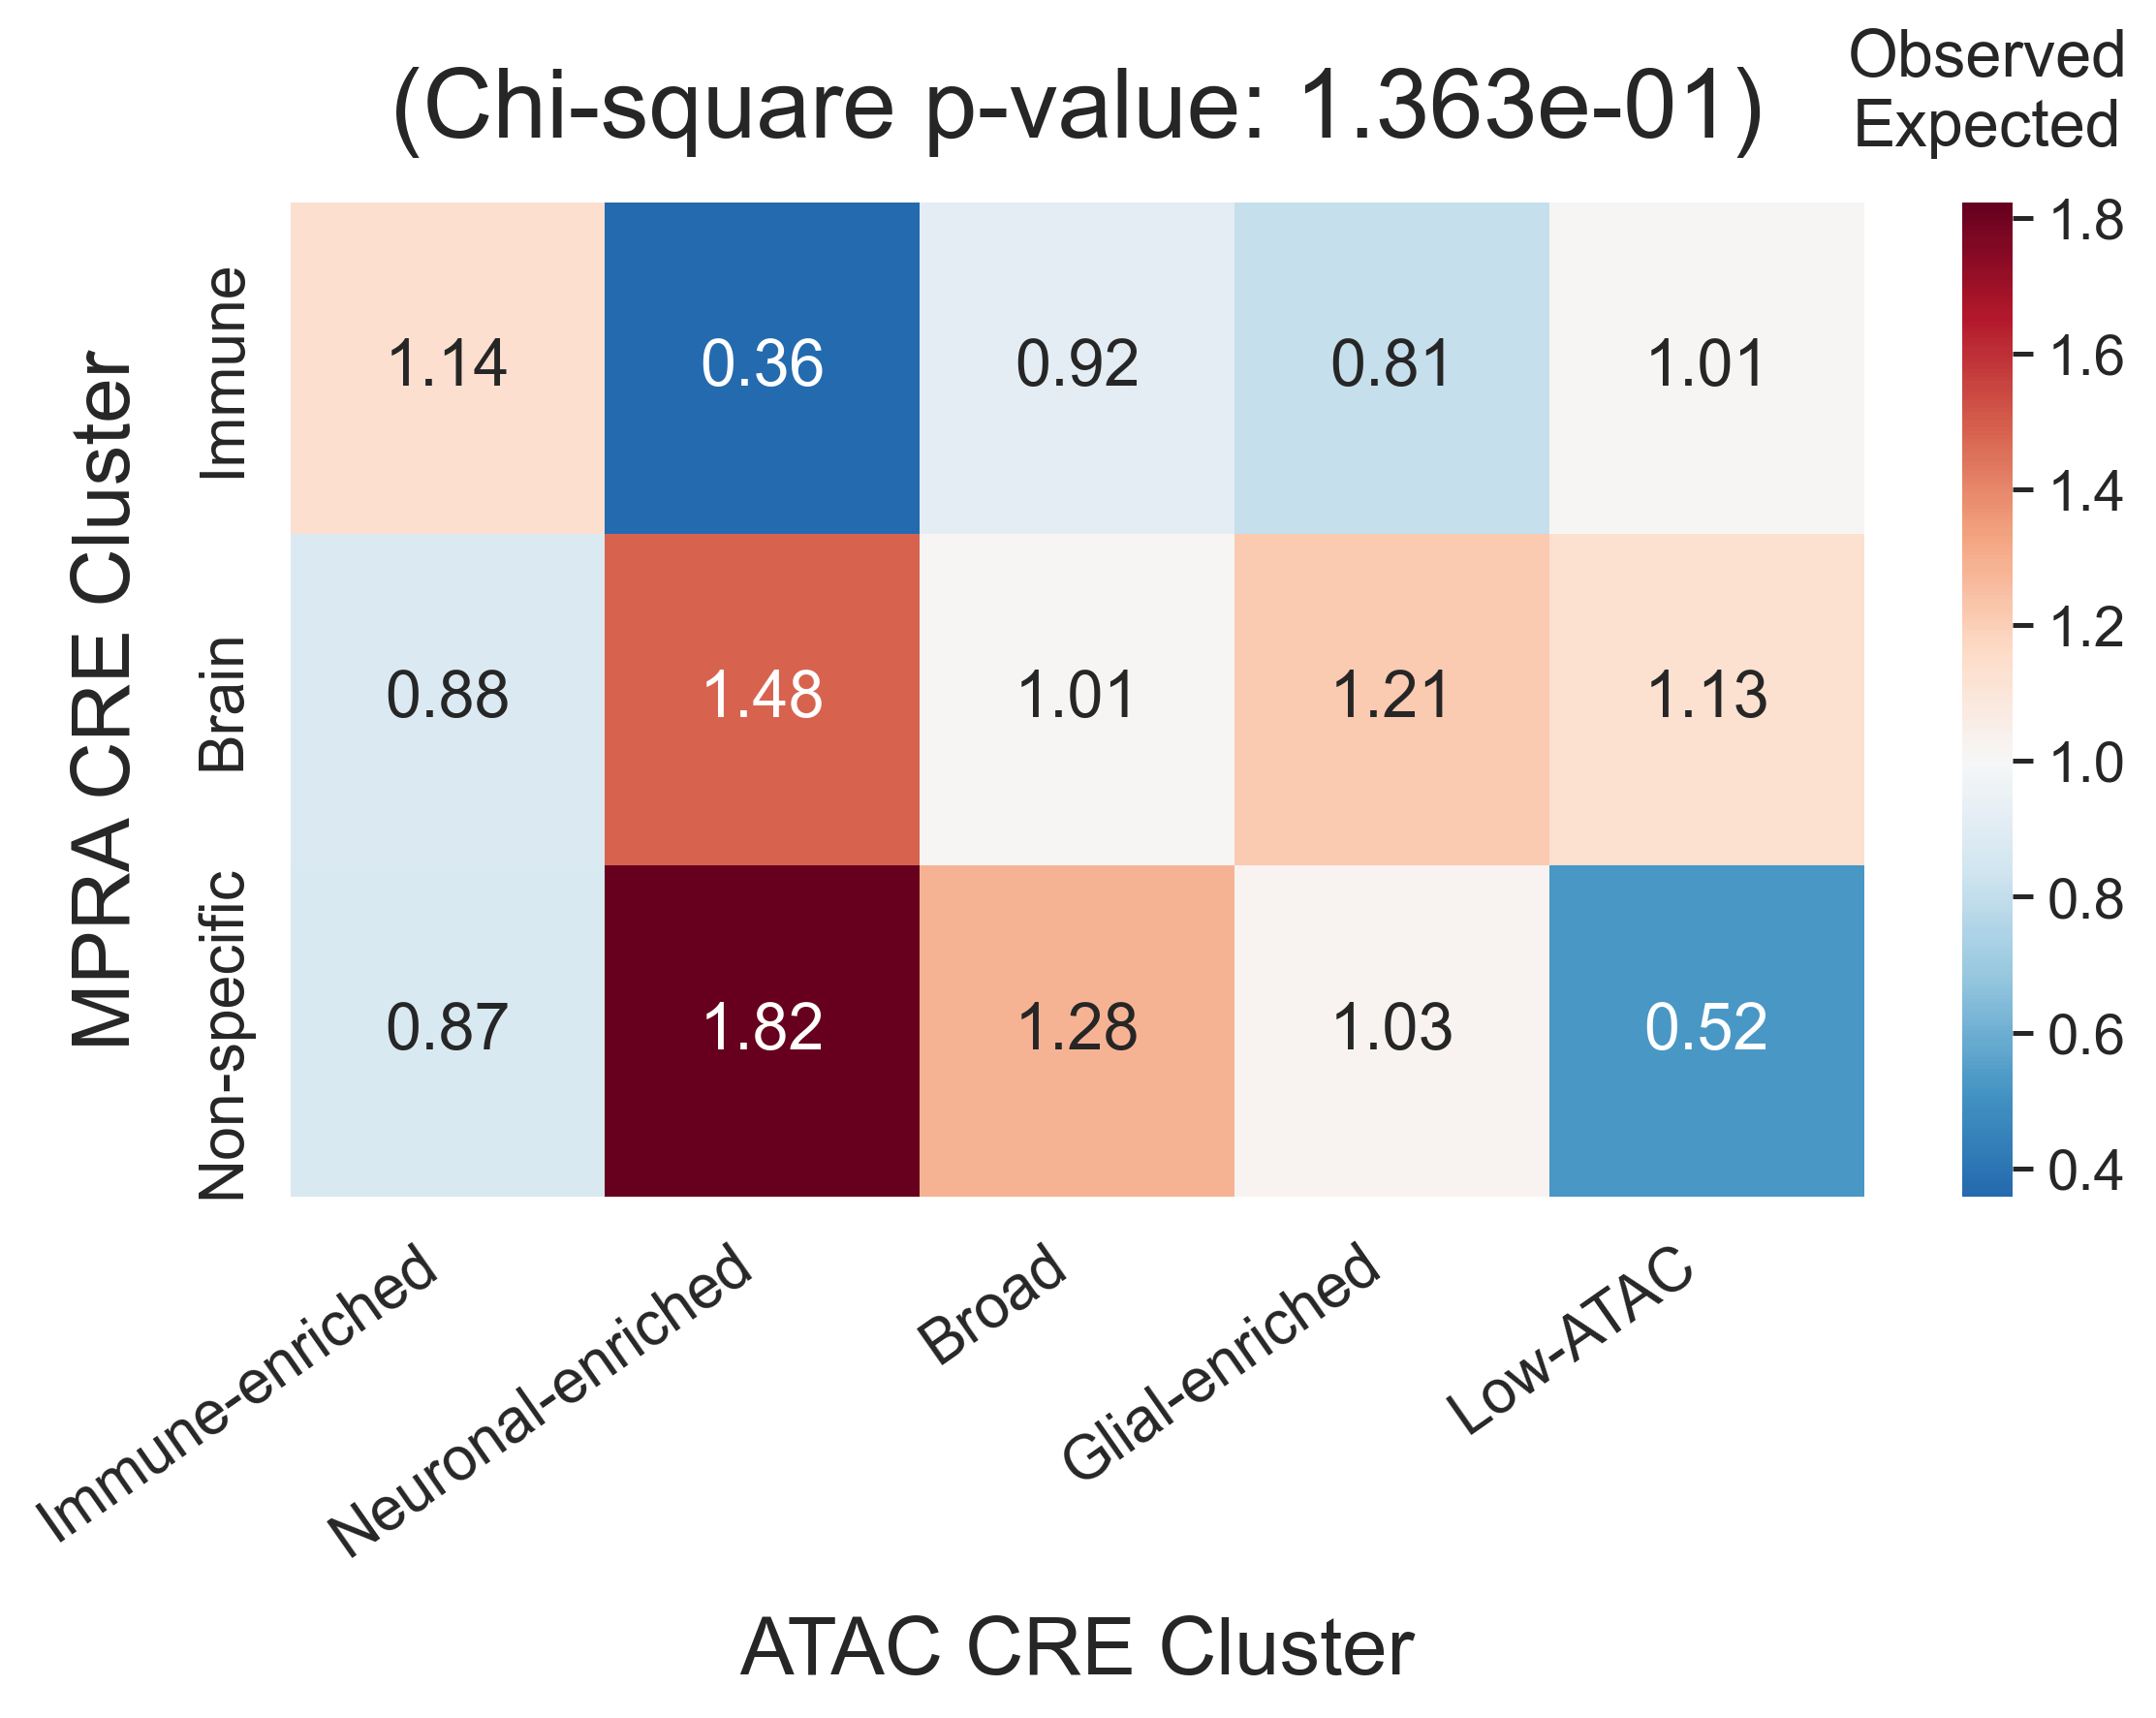

In [14]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

# =========================================================
# Make text editable in Illustrator
# =========================================================
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.family'] = 'Arial'

# =========================================================
# 1. settings
# =========================================================
p_thresh = 0.05
brain_col = 'Brain'
immune_col = 'THP1Macrophage'

row_order = ['Immune', 'Brain', 'Non-specific']
col_order = [
    'Immune-enriched',
    'Neuronal-enriched',
    'Broad',
    'Glial-enriched',
    'Low-ATAC'
]

# =========================================================
# 2. prepare dataframe
# =========================================================
df_plot = df_mpra_annotation_unique.copy()

df_plot = df_plot[
    df_plot['Variant_Category'].isin(col_order)
].copy()

df_plot[brain_col] = pd.to_numeric(df_plot[brain_col], errors='coerce')
df_plot[immune_col] = pd.to_numeric(df_plot[immune_col], errors='coerce')
df_plot = df_plot.dropna(subset=[brain_col, immune_col]).copy()

# =========================================================
# 3. define MPRA CRE cluster
# =========================================================
brain_sig = df_plot[brain_col] <= p_thresh
immune_sig = df_plot[immune_col] <= p_thresh

df_plot['MPRA_CRE_Cluster'] = np.select(
    [
        immune_sig & ~brain_sig,
        brain_sig & ~immune_sig,
        brain_sig & immune_sig,
    ],
    [
        'Immune',
        'Brain',
        'Non-specific',
    ],
    default='Not-significant'
)

# 去掉两边都不显著的
df_plot = df_plot.dropna(subset=['MPRA_CRE_Cluster']).copy()

# 直接保留原始 ATAC 分类
df_plot['ATAC_CRE_Cluster'] = df_plot['Variant_Category']

# =========================================================
# 4. contingency table
# =========================================================
contingency = pd.crosstab(
    df_plot['MPRA_CRE_Cluster'],
    df_plot['ATAC_CRE_Cluster']
).reindex(index=row_order, columns=col_order, fill_value=0)

print("Contingency table:")
print(contingency)

# =========================================================
# 5. chi-square test
# =========================================================
chi2, pval, dof, expected = chi2_contingency(contingency)

expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

obs_over_exp = contingency / expected_df

print("\nExpected table:")
print(expected_df)

print("\nObserved / Expected:")
print(obs_over_exp)

# =========================================================
# 6. plot heatmap
# =========================================================
sns.set(style="white", context="paper")

fig, ax = plt.subplots(figsize=(8,6), dpi=300)

hm = sns.heatmap(
    obs_over_exp,
    cmap='RdBu_r',
    center=1.0,
    annot=True,
    fmt='.2f',
    linewidths=0,
    cbar=True,
    annot_kws={'fontsize': 16},
    ax=ax
)

ax.set_xlabel('ATAC CRE Cluster', fontsize=20, labelpad=12)
ax.set_ylabel('MPRA CRE Cluster', fontsize=20, labelpad=12)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va='center', fontsize=16)

ax.set_title(f'(Chi-square p-value: {pval:.3e})', fontsize=24, pad=16)

ax.tick_params(
    axis='both',
    which='both',
    direction='out',
    length=6,
    width=1.5,
    labelsize=15
)

# colorbar
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14, width=1.2, length=5)
cbar.ax.set_title('Observed\nExpected', fontsize=16, pad=14)

plt.tight_layout()

plt.savefig(
    'chi_square_obs_over_exp_heatmap_5categories.pdf',
    bbox_inches='tight'
)
plt.savefig(
    'chi_square_obs_over_exp_heatmap_5categories.svg',
    bbox_inches='tight'
)

plt.show()